Info: Node 0 is Ground (skipped). This is correct.
Starting Solver..
Solver finished.


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `mass`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


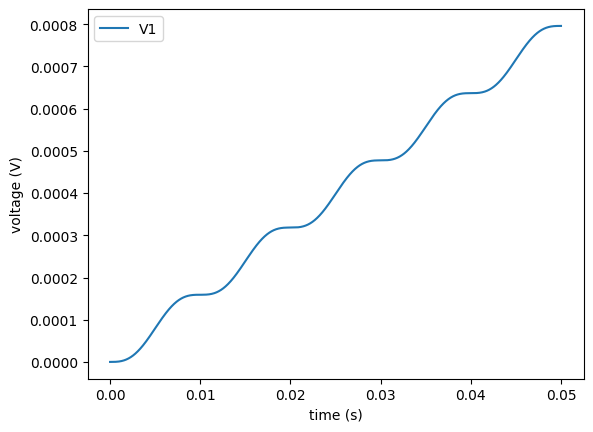

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

#functions
def get_all_nodes(*dfs):
    nodes = set()
    for df in dfs:
        nodes.update(df['node1'])
        nodes.update(df['node2'])
    nodes.discard(0)  
    return sorted(nodes)

def stamp_resistor(G, n1_idx, n2_idx, R):
    Y = 1 / R
    if n1_idx is not None:
        G[n1_idx, n1_idx] += Y
    if n2_idx is not None:
        G[n2_idx, n2_idx] += Y
    if n1_idx is not None and n2_idx is not None:
        G[n1_idx, n2_idx] -= Y
        G[n2_idx, n1_idx] -= Y
        
def stamp_capacitor(C, n1_idx, n2_idx, C_value):
    if n1_idx is not None:
        C[n1_idx, n1_idx] += C_value
    if n2_idx is not None:
        C[n2_idx, n2_idx] += C_value
    if n1_idx is not None and n2_idx is not None:
        C[n1_idx, n2_idx] -= C_value
        C[n2_idx, n1_idx] -= C_value
        

def stamp_inductor(G, C, n1_idx, n2_idx, ind_idx, L_value,):
    if n1_idx is not None:
        G[n1_idx, ind_idx] += 1
        G[ind_idx, n1_idx] += 1
    if n2_idx is not None:
        G[n2_idx, ind_idx] -= 1
        G[ind_idx, n2_idx] -= 1
    C[ind_idx, ind_idx] = L_value
    
def stamp_voltage_G(G, n1_idx, n2_idx, V_idx):
    if n1_idx is not None:
        G[n1_idx, V_idx] += 1
        G[V_idx, n1_idx] += 1
    if n2_idx is not None:
        G[n2_idx, V_idx] -= 1
        G[V_idx, n2_idx] -= 1
    
def stamp_voltage_ft(f_t, V_idx, V_value):
        f_t[V_idx] = V_value
    
def stamp_current(f_t, n1_idx, n2_idx, I_value):
    if n1_idx is not None:
        f_t[n1_idx] -= I_value
    if n2_idx is not None:
        f_t[n2_idx] += I_value
                    
def circuit_solver(filename):
    with open(filename, 'r') as f:
        netlist_data = json.load(f) 
    components_df = pd.DataFrame(netlist_data['components'])
    components_df['node1'] = components_df['node1'].astype(int)
    components_df['node2'] = components_df['node2'].astype(int)
    
    passive_comp = ['resistor', 'capacitor', 'inductor']
    source_comp = ['voltage-source', 'current-source']
    passive_comp_df = components_df[components_df['type'].isin(passive_comp)].copy()
    source_df = components_df[components_df['type'].isin(source_comp)].copy()
    passive_comp_df.reset_index(drop=True, inplace=True)
    source_df.reset_index(drop=True, inplace=True)
    
    # add source definitions to columns
    source_df['source_type'] = source_df['source_definition'].apply(
        lambda sd: sd.get('type') if isinstance(sd, dict) else None
    )
    source_df['phase_angle'] = source_df['source_definition'].apply(
        lambda sd: sd.get('phase_angle', 0) if isinstance(sd, dict) else 0
    )
    source_df['frequency'] = source_df['source_definition'].apply(
        lambda sd: sd.get('frequency') if isinstance(sd, dict) else None
    )
    source_df = source_df.drop(columns = ['source_definition'])
   
    # counting components and nodes
    node_list = get_all_nodes(passive_comp_df, source_df)
    n = len(node_list)
    n_resistor = (passive_comp_df['type'] == 'resistor').sum()
    n_capacitor = (passive_comp_df['type'] == 'capacitor').sum()
    n_inductor = (passive_comp_df['type'] == 'inductor').sum()
    num_V = (source_df['type'] == 'voltage-source').sum()
    num_I = (source_df['type'] == 'current-source').sum()
    m = num_V + n_inductor 
     
    #index mapping
    node_map = {node: idx for idx, node in enumerate(node_list)} #node voltages
    vsources = source_df[source_df["type"] == "voltage-source"]
    vs_map = {int(idx): int(len(node_list) + i) for i, idx in enumerate(vsources.index)} #voltage source current
    inductors = passive_comp_df[passive_comp_df["type"] == "inductor"]
    ind_map = {int(idx): int(len(node_list) + num_V + i) for i, idx in enumerate(inductors.index)} #inductor current
    
    # print("Number of each component: \n R:", n_resistor, ", C:", n_capacitor, ", L:", n_inductor)
    # print ("Number of sources:")
    # print ("Voltage sources:", num_V, "Current Sources:", num_I)
      
    # Initialize matrices
    G = np.zeros([n+m, n+m])
    C = np.zeros([n+m, n+m])
    f_t = np.zeros(n+m)
    # x = np.zeros(n + num_V + n_inductor)
    x0 = np.zeros(n + num_V + n_inductor) #for initial conditions
    
    
    # Matrix stamping of G and C matrices
    for idx,comp in passive_comp_df.iterrows():
        type = comp['type']
        n1 = comp['node1']
        n2 = comp['node2']
        value = float(comp['value'])
        n1_idx = node_map.get(n1)
        n2_idx = node_map.get(n2)
        if type == 'resistor':
            stamp_resistor(G, n1_idx, n2_idx, value)
        elif type == 'capacitor':
            stamp_capacitor(C, n1_idx, n2_idx, value)
        elif type == 'inductor':
            ind_idx = ind_map[idx]
            stamp_inductor(G, C, n1_idx, n2_idx, ind_idx, value)
    
    for idx, comp in source_df.iterrows():
        type = comp['type']
        n1 = comp['node1']
        n2 = comp['node2']
        n1_idx = node_map.get(n1)
        n2_idx = node_map.get(n2)
        
        # CORRECT DEBUG LOGIC
        if n1 != 0 and n1_idx is None: 
            print(f">>> REAL ERROR: Node {n1} is missing from the map!")
        elif n1 == 0:
            print(f"Info: Node {n1} is Ground (skipped). This is correct.")
    
        value = float(comp['value'])
        if type == 'voltage-source':
            V_idx = vs_map[idx]
            stamp_voltage_G(G, n1_idx, n2_idx, V_idx)       
    #stamping ends
    
    ac_sources = []
    dc_sources = []
    
    for idx, comp in source_df.iterrows():
        type = comp['type']
        n1 = comp['node1']
        n2 = comp['node2']
        n1_idx = node_map.get(n1)
        n2_idx = node_map.get(n2)
        source_type = comp['source_type']
        value = float(comp['value'])
        phase_angle = np.deg2rad(comp['phase_angle']) 
        frequency = float(comp['frequency'])
        indices = []
        signs = []
        if type == 'voltage-source':
            indices.append(vs_map[idx])
            signs.append(1.0)
        elif type == 'current-source':
            if n1_idx is not None:
                indices.append(n1_idx)
                signs.append(-1.0)
            if n2_idx is not None:
                indices.append(n2_idx)
                signs.append(1.0)
        
        source_data = {
            'indices': indices,
            'signs': signs,
            'value': value,
            'frequency': frequency,
            'phase_angle': phase_angle
        }
        
        if source_type == 'ac':
            ac_sources.append(source_data)
        else:
            dc_sources.append(source_data)
    
    #odes 
    def circuit_odes(t, x):
        F = np.zeros(n + m)
        
        for src in dc_sources:
            for i, idx in enumerate(src['indices']):
                F[idx] += src['signs'][i] * src['value']
                
        if t > 0: # Avoid div by zero or initial artifacts if needed
            for src in ac_sources:
                # V = A * sin(2*pi*f*t + phi)
                val = src['value'] * np.sin(2 * np.pi * src['frequency'] * t + src['phase_angle'])
                for i, idx in enumerate(src['indices']):
                    F[idx] += src['signs'][i] * val
                    
        return F - (G @ x)
    
    t_span = (0, 0.05) #plot from t = 0 to t = 0.05
    
    #Run simulation
    print("Starting Solver..")
    sol = solve_ivp(
        fun=circuit_odes,          # Explicitly name the function
        t_span=t_span,             # Time span
        y0=x0,                     # Initial conditions
        method="Radau",            # <--- MUST BE "Radau" or "BDF"
        t_eval=np.linspace(t_span[0], t_span[1], num=2000),
        mass=C,                    # The Mass Matrix (Crucial!)
        jac=lambda t, x: -G,       # The Jacobian
        atol=1e-6,
        rtol=1e-6
    )
    print("Solver finished.")
    # print(sol)
    
    plt.plot( sol.t, sol.y[node_map[1]], label = 'V1')
    plt.xlabel('time (s)')
    plt.ylabel('voltage (V)')
    plt.legend()
    plt.show()
    
            
file = 'netlist.json'
circuit_solver(file)
            

In [5]:
import scipy
print(f"Scipy Version: {scipy.__version__}")

Scipy Version: 1.16.3
